In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [3]:
# Load the cleaned retail dataset

file_path = "/content/drive/MyDrive/Retail Analytics System/data/cleaned/clean_retail.csv"

df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [4]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  object        
 8   Revenue      779425 non-null  float64       
 9   Year         779425 non-null  int64         
 10  Month        779425 non-null  int64         
 11  Day          779425 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 71.4+ MB


In [5]:
# Create snapshot date: one day after the latest purchase date

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Last Purchase Date:", df['InvoiceDate'].max())
print("Snapshot Date:", snapshot_date)

Last Purchase Date: 2011-12-09 12:50:00
Snapshot Date: 2011-12-10 12:50:00


In [6]:
# ---------------------------------------
# Calculate Last Purchase Date per Customer
# ---------------------------------------

churn = df.groupby('Customer ID').agg({
    'InvoiceDate': 'max'
}).reset_index()

# Rename column
churn.rename(columns={'InvoiceDate': 'Last_Purchase_Date'}, inplace=True)

# Calculate Days Since Last Purchase
churn['Days_Since_Last_Purchase'] = (
    snapshot_date - churn['Last_Purchase_Date']
).dt.days

# Display first 10 customers
churn.head(10)

,Customer ID,Last_Purchase_Date,Days_Since_Last_Purchase
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310
5,12351,2010-11-29 15:23:00,375
6,12352,2011-11-03 14:37:00,36
7,12353,2011-05-19 17:47:00,204
8,12354,2011-04-21 13:11:00,232
9,12355,2011-05-09 13:49:00,214


In [7]:
# ---------------------------------------
# Create Customer Churn Segments
# ---------------------------------------

def classify_customer(days):
    if days <= 30:
        return "Active"
    elif days <= 90:
        return "At Risk"
    else:
        return "Churned"

churn['Churn_Status'] = churn['Days_Since_Last_Purchase'].apply(classify_customer)

# Display first 10 rows
churn.head(10)

,Customer ID,Last_Purchase_Date,Days_Since_Last_Purchase,Churn_Status
0,12346,2011-01-18 10:01:00,326,Churned
1,12347,2011-12-07 15:52:00,2,Active
2,12348,2011-09-25 13:13:00,75,At Risk
3,12349,2011-11-21 09:51:00,19,Active
4,12350,2011-02-02 16:01:00,310,Churned
5,12351,2010-11-29 15:23:00,375,Churned
6,12352,2011-11-03 14:37:00,36,At Risk
7,12353,2011-05-19 17:47:00,204,Churned
8,12354,2011-04-21 13:11:00,232,Churned
9,12355,2011-05-09 13:49:00,214,Churned


In [8]:
# ---------------------------------------
# Calculate Overall Churn Rate
# ---------------------------------------

total_customers = len(churn)

churned_customers = len(
    churn[churn['Churn_Status'] == 'Churned']
)

churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers      : {total_customers}")
print(f"Churned Customers    : {churned_customers}")
print(f"Overall Churn Rate   : {churn_rate:.2f}%")

Total Customers      : 5878
Churned Customers    : 2989
Overall Churn Rate   : 50.85%


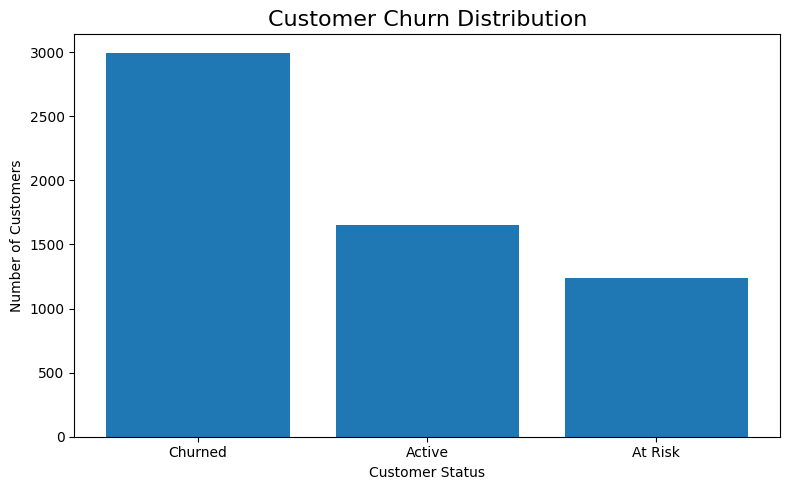

In [9]:
# ---------------------------------------
# Customer Churn Distribution
# ---------------------------------------

churn_summary = (
    churn['Churn_Status']
    .value_counts()
    .reset_index()
)

churn_summary.columns = ['Churn_Status', 'Customer_Count']

plt.figure(figsize=(8,5))

plt.bar(
    churn_summary['Churn_Status'],
    churn_summary['Customer_Count']
)

plt.title('Customer Churn Distribution', fontsize=16)
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [10]:
# ---------------------------------------
# Add Country to Churn Table
# ---------------------------------------

customer_country = (
    df[['Customer ID', 'Country']]
    .drop_duplicates()
)

churn = churn.merge(
    customer_country,
    on='Customer ID',
    how='left'
)

# Display first 10 rows
churn.head(10)

,Customer ID,Last_Purchase_Date,Days_Since_Last_Purchase,Churn_Status,Country
0,12346,2011-01-18 10:01:00,326,Churned,United Kingdom
1,12347,2011-12-07 15:52:00,2,Active,Iceland
2,12348,2011-09-25 13:13:00,75,At Risk,Finland
3,12349,2011-11-21 09:51:00,19,Active,Italy
4,12350,2011-02-02 16:01:00,310,Churned,Norway
5,12351,2010-11-29 15:23:00,375,Churned,Unspecified
6,12352,2011-11-03 14:37:00,36,At Risk,Norway
7,12353,2011-05-19 17:47:00,204,Churned,Bahrain
8,12354,2011-04-21 13:11:00,232,Churned,Spain
9,12355,2011-05-09 13:49:00,214,Churned,Bahrain


In [11]:
# ---------------------------------------
# Churned Customers by Country
# ---------------------------------------

churn_by_country = (
    churn[churn['Churn_Status'] == 'Churned']
    .groupby('Country')
    .size()
    .reset_index(name='Churned_Customers')
    .sort_values(by='Churned_Customers', ascending=False)
)

# Display top 10 countries
churn_by_country.head(10)

,Country,Churned_Customers
35,United Kingdom,2737
13,Germany,38
12,France,34
29,Spain,18
22,Netherlands,16
30,Sweden,14
26,Portugal,12
3,Belgium,11
31,Switzerland,10
6,Channel Islands,9


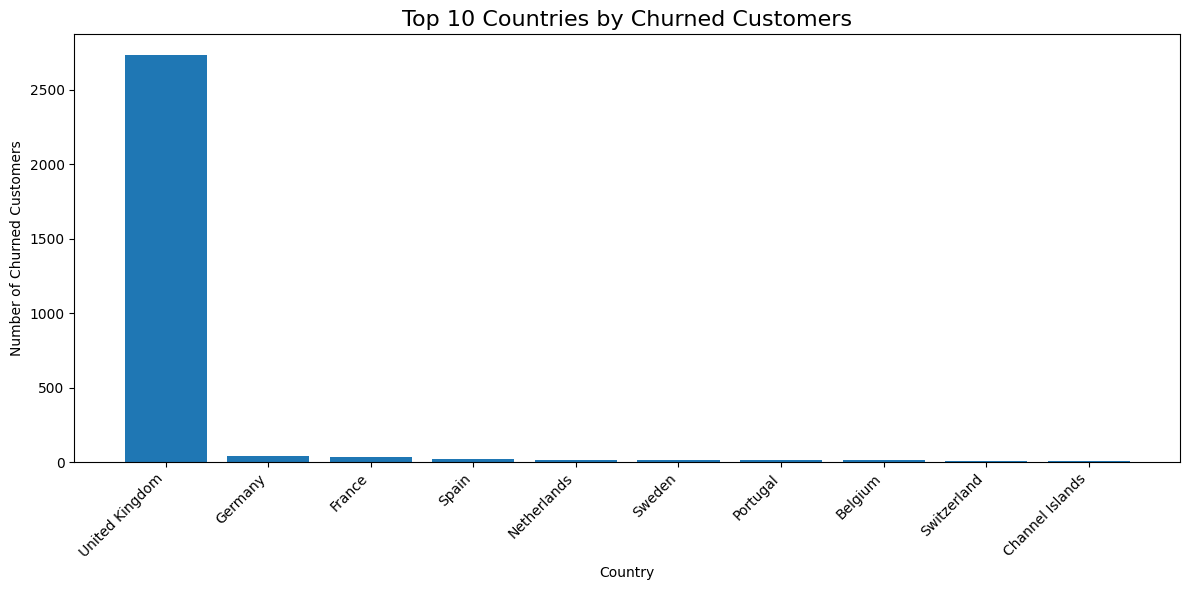

In [12]:
# ---------------------------------------
# Top 10 Churn by Country Chart
# ---------------------------------------

top10 = churn_by_country.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['Country'],
    top10['Churned_Customers']
)

plt.title('Top 10 Countries by Churned Customers', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Churned Customers')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

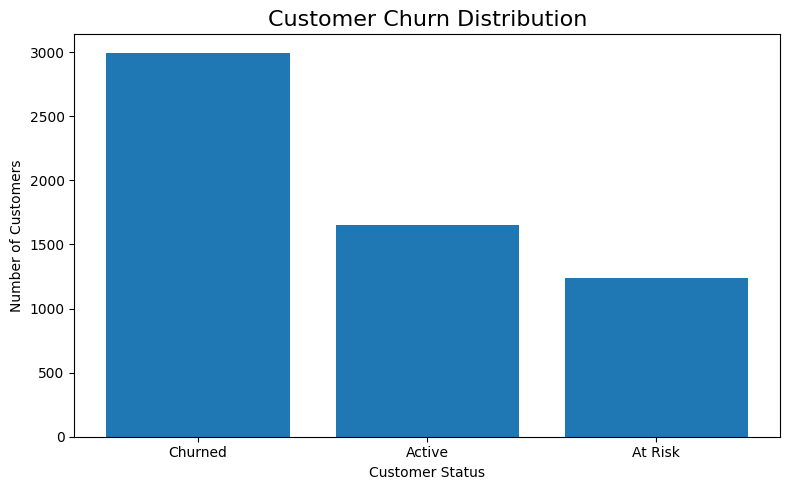

Customer Churn Distribution chart saved successfully!


In [13]:
# Save Customer Churn Distribution Chart

plt.figure(figsize=(8,5))

plt.bar(
    churn_summary['Churn_Status'],
    churn_summary['Customer_Count']
)

plt.title('Customer Churn Distribution', fontsize=16)
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Retail Analytics System/screenshots/customer_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Customer Churn Distribution chart saved successfully!")

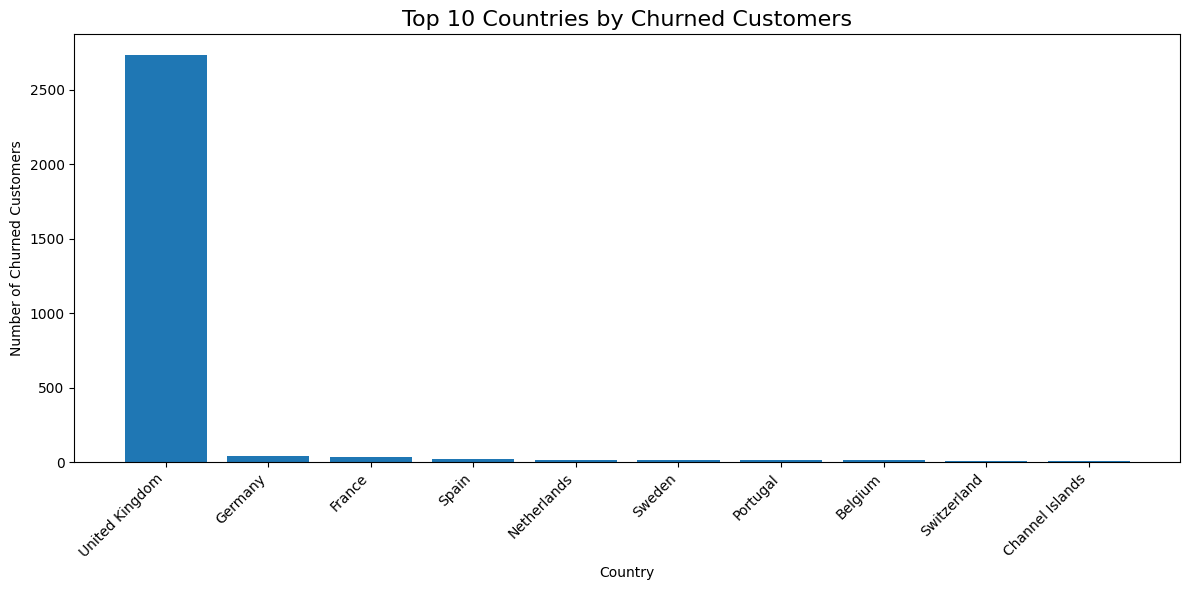

Top 10 Churn by Country chart saved successfully!


In [14]:
# Save Top 10 Countries by Churned Customers Chart

top10 = churn_by_country.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['Country'],
    top10['Churned_Customers']
)

plt.title('Top 10 Countries by Churned Customers', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Churned Customers')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Retail Analytics System/screenshots/top10_churn_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top 10 Churn by Country chart saved successfully!")

In [15]:
# ---------------------------------------
# Export Customer Churn Analysis
# ---------------------------------------

output_path = "/content/drive/MyDrive/Retail Analytics System/data/cleaned/churn_analysis.csv"

churn.to_csv(output_path, index=False)

print("Customer Churn Analysis exported successfully!")

Customer Churn Analysis exported successfully!
